In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
from torchvision import models, transforms
from PIL import Image
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Load data
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)
classes = data['classes']

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_balanced.pth', map_location='cpu'))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Model loaded!")
print(f"Classes: {len(classes)}")

Model loaded!
Classes: 15


True label:      Pepper__bell___healthy
Predicted label: Pepper__bell___healthy
Confidence:      99.95%


/opt/anaconda3/envs/cropai/lib/python3.10/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: divide by zero encountered in matmul
  projection = reshaped_activations @ VT[0, :]
/opt/anaconda3/envs/cropai/lib/python3.10/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: overflow encountered in matmul
  projection = reshaped_activations @ VT[0, :]
/opt/anaconda3/envs/cropai/lib/python3.10/site-packages/pytorch_grad_cam/utils/svd_on_activations.py:17: RuntimeWarning: invalid value encountered in matmul
  projection = reshaped_activations @ VT[0, :]


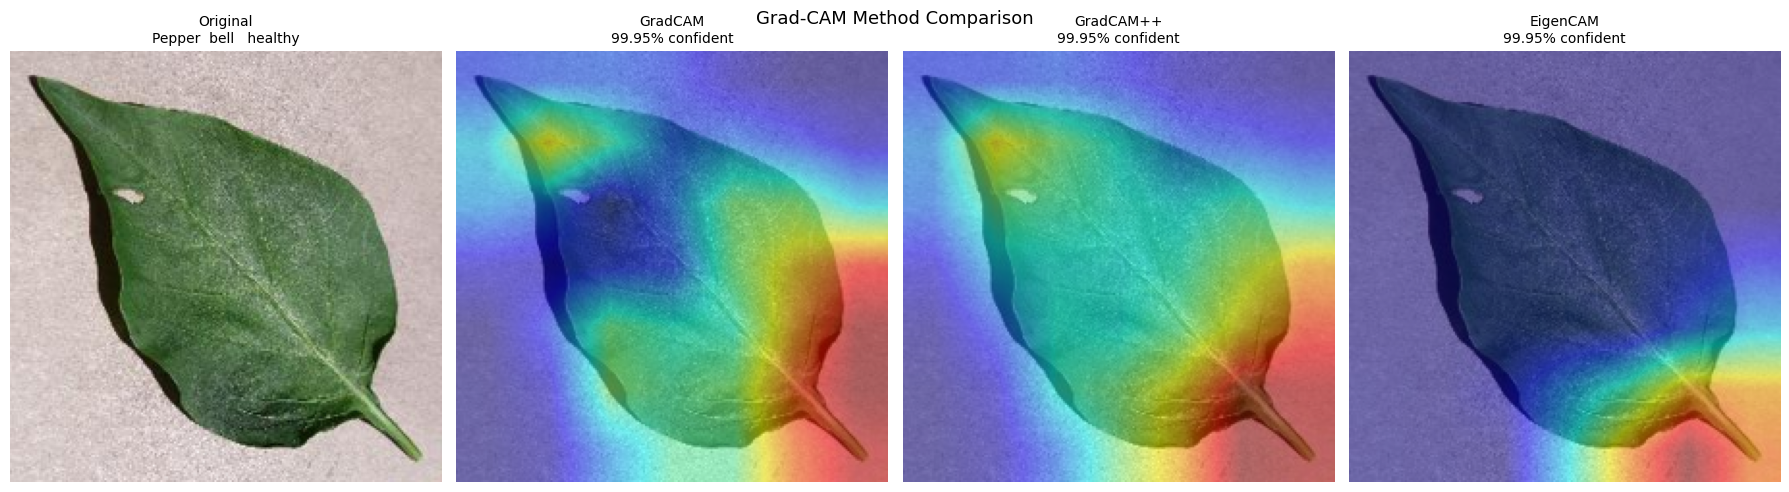

Saved to outputs/gradcam/method_comparison.png


In [2]:
# Pick a test image
test_path = data['test_paths'][5]
test_label = classes[data['test_labels'][5]]

orig_img = Image.open(test_path).convert('RGB')
orig_resized = orig_img.resize((224, 224))
orig_np = np.array(orig_resized) / 255.0
img_tensor = transform(orig_img).unsqueeze(0)

# Get prediction
with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    conf, pred = probs.max(1)
predicted_class = classes[pred.item()]
confidence = round(conf.item() * 100, 2)

print(f"True label:      {test_label}")
print(f"Predicted label: {predicted_class}")
print(f"Confidence:      {confidence}%")

# Compare 3 CAM methods
target_layer = [model.layer4[-1]]
cam_methods = {
    'GradCAM':       GradCAM(model=model, target_layers=target_layer),
    'GradCAM++':     GradCAMPlusPlus(model=model, target_layers=target_layer),
    'EigenCAM':      EigenCAM(model=model, target_layers=target_layer),
}

targets = [ClassifierOutputTarget(pred.item())]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(orig_resized)
axes[0].set_title(f'Original\n{test_label.replace("_"," ")}', fontsize=10)
axes[0].axis('off')

# Each CAM method
for i, (name, cam) in enumerate(cam_methods.items()):
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
    visualization = show_cam_on_image(orig_np.astype(np.float32),
                                       grayscale_cam, use_rgb=True)
    axes[i+1].imshow(visualization)
    axes[i+1].set_title(f'{name}\n{confidence}% confident', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Grad-CAM Method Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/gradcam/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/gradcam/method_comparison.png")

True label:      Tomato_Early_blight
Predicted label: Tomato_Early_blight
Confidence:      100.0%


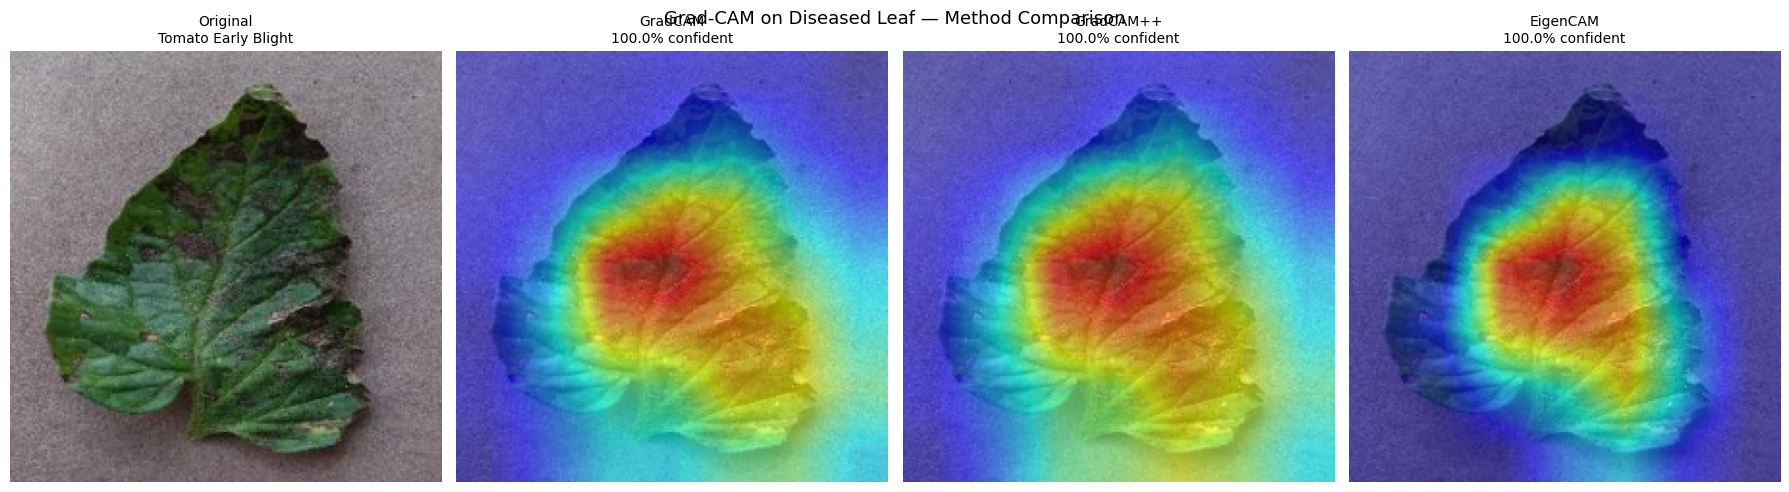

Saved to outputs/gradcam/diseased_comparison.png


In [3]:
# Find a diseased leaf — Tomato Early Blight
class_idx = classes.index('Tomato_Early_blight')
diseased_paths = [(p, l) for p, l in zip(data['test_paths'], data['test_labels']) 
                  if l == class_idx]
test_path = diseased_paths[0][0]

orig_img = Image.open(test_path).convert('RGB')
orig_resized = orig_img.resize((224, 224))
orig_np = np.array(orig_resized) / 255.0
img_tensor = transform(orig_img).unsqueeze(0)

with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    conf, pred = probs.max(1)
predicted_class = classes[pred.item()]
confidence = round(conf.item() * 100, 2)

print(f"True label:      Tomato_Early_blight")
print(f"Predicted label: {predicted_class}")
print(f"Confidence:      {confidence}%")

targets = [ClassifierOutputTarget(pred.item())]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(orig_resized)
axes[0].set_title('Original\nTomato Early Blight', fontsize=10)
axes[0].axis('off')

cam_methods = {
    'GradCAM':   GradCAM(model=model, target_layers=[model.layer4[-1]]),
    'GradCAM++': GradCAMPlusPlus(model=model, target_layers=[model.layer4[-1]]),
    'EigenCAM':  EigenCAM(model=model, target_layers=[model.layer4[-1]]),
}

for i, (name, cam) in enumerate(cam_methods.items()):
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
    visualization = show_cam_on_image(orig_np.astype(np.float32),
                                       grayscale_cam, use_rgb=True)
    axes[i+1].imshow(visualization)
    axes[i+1].set_title(f'{name}\n{confidence}% confident', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Grad-CAM on Diseased Leaf — Method Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/gradcam/diseased_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/gradcam/diseased_comparison.png")

In [4]:
new_api = open('src/api.py').read().replace(
    'from pytorch_grad_cam import GradCAM',
    'from pytorch_grad_cam import GradCAMPlusPlus'
).replace(
    'GRAD_CAM = GradCAM(model=RESNET, target_layers=[RESNET.layer4[-1]])',
    'GRAD_CAM = GradCAMPlusPlus(model=RESNET, target_layers=[RESNET.layer4[-1]])'
)

with open('src/api.py', 'w') as f:
    f.write(new_api)

print("API updated to use GradCAM++!")

API updated to use GradCAM++!


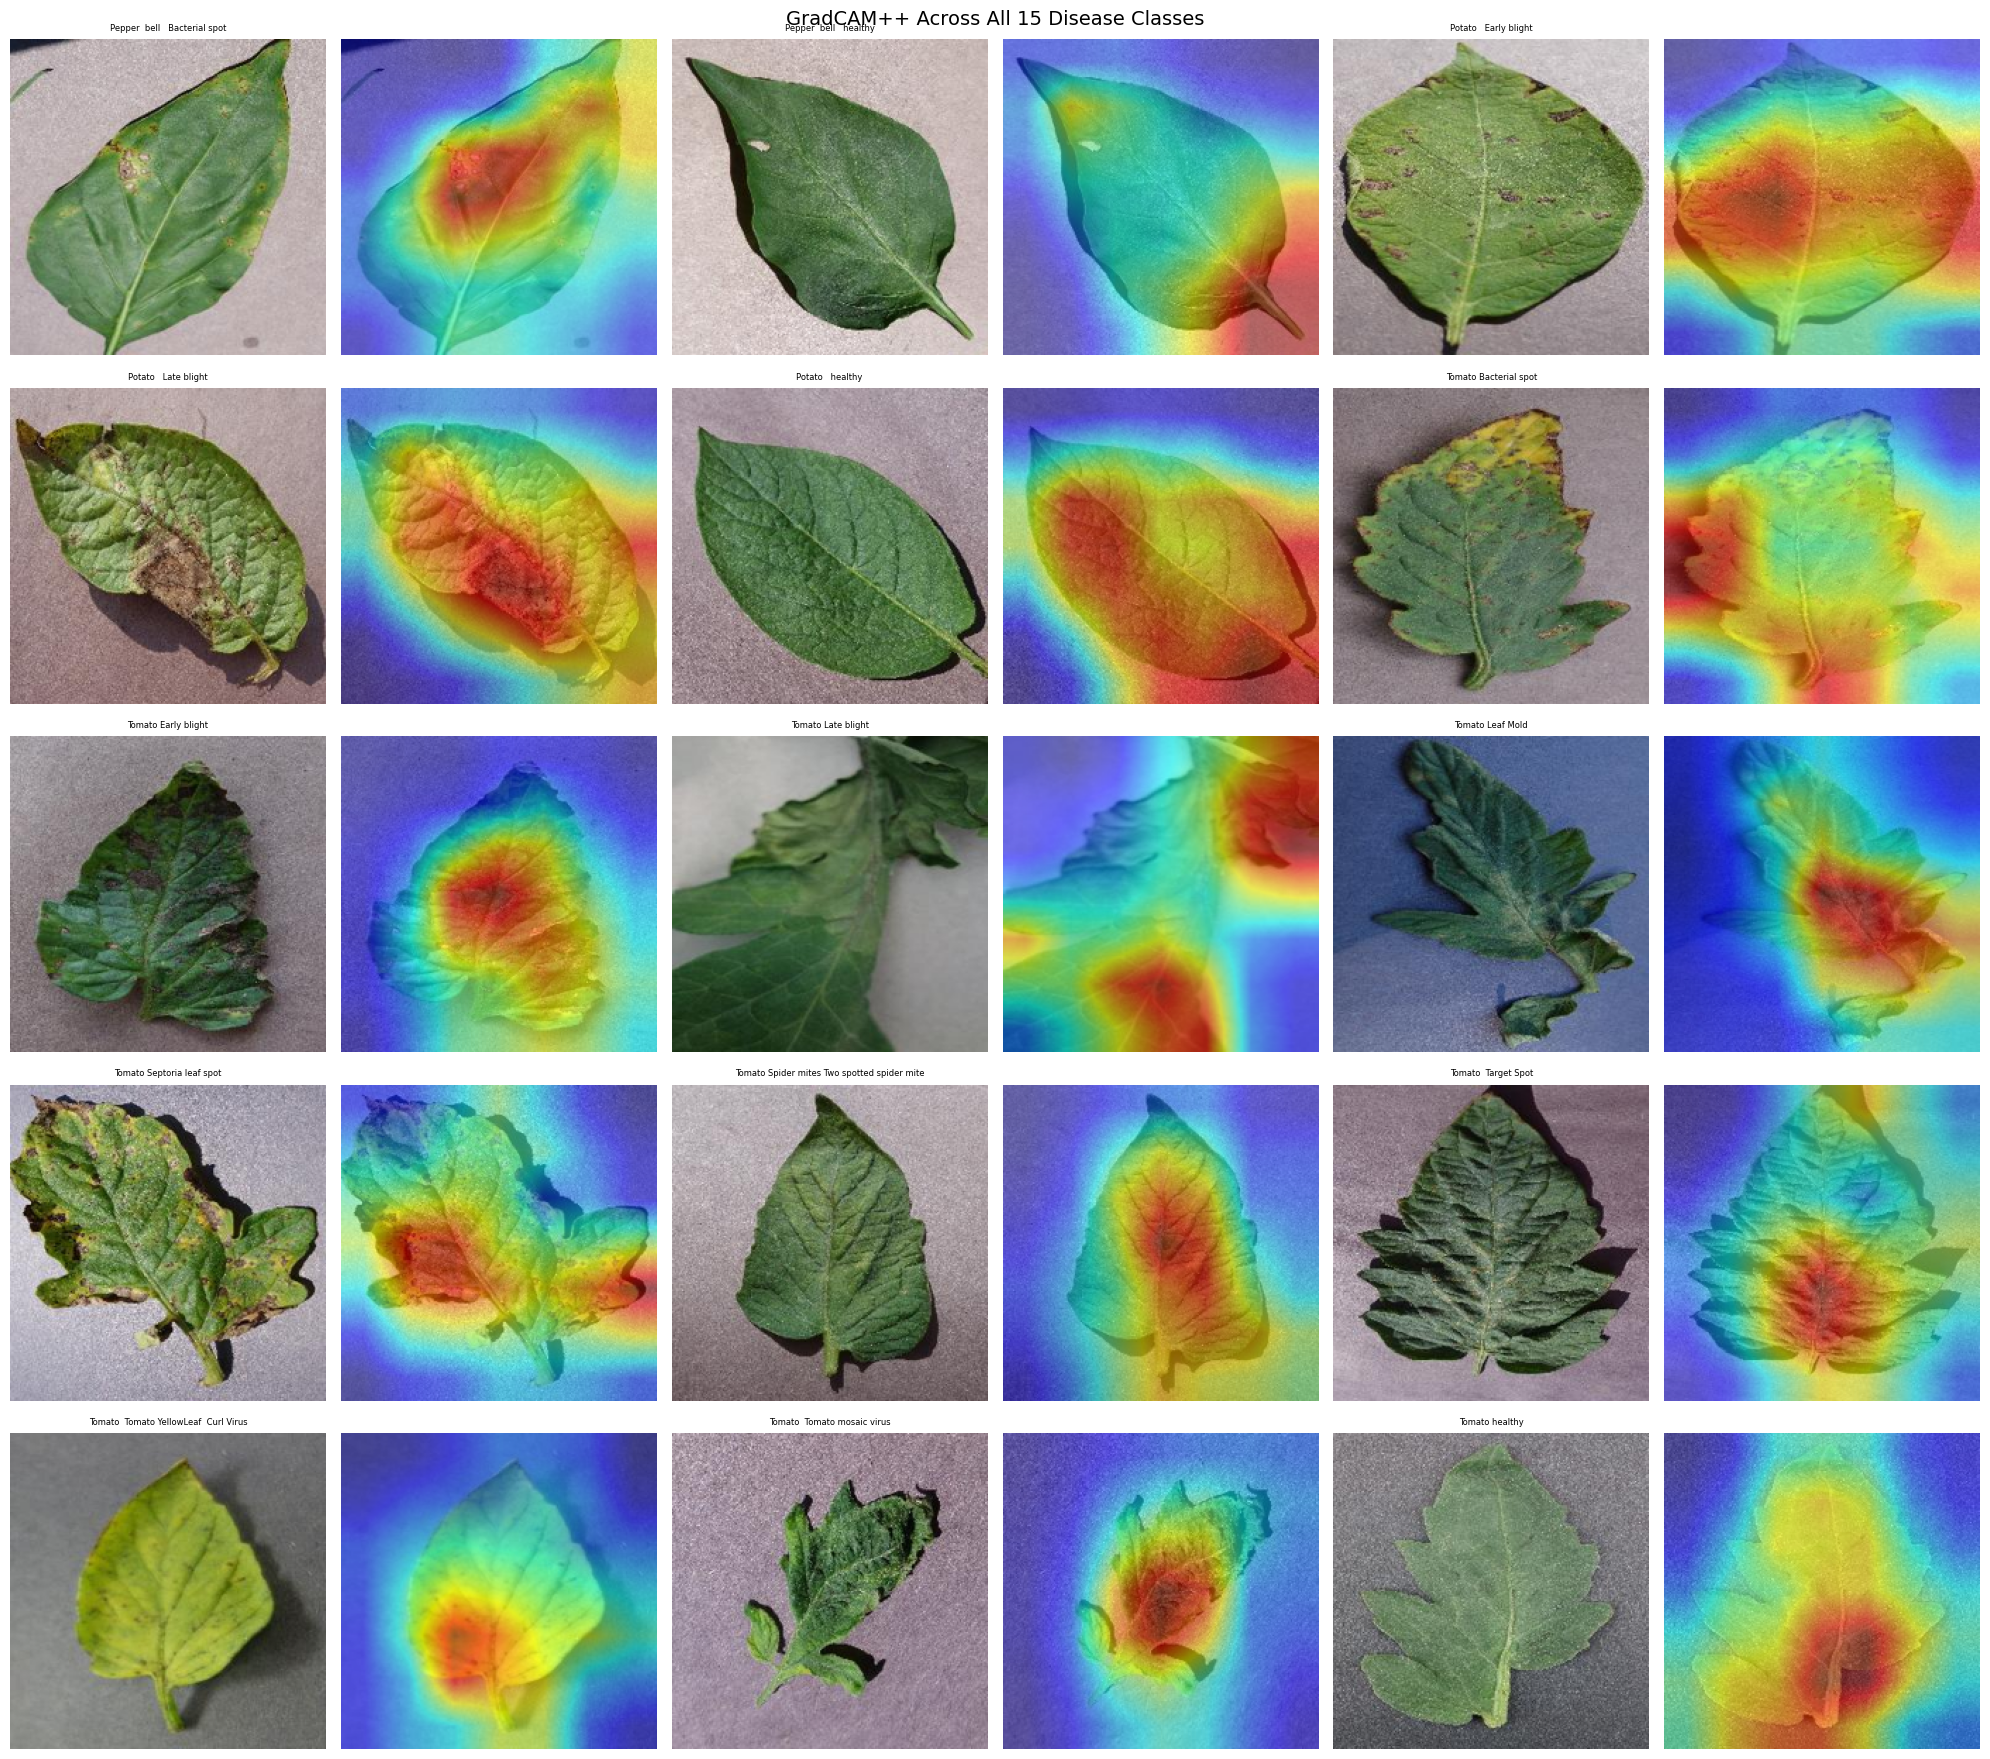

Saved to outputs/gradcam/all_classes_gradcam.png


In [5]:
import warnings
warnings.filterwarnings('ignore')

cam = GradCAMPlusPlus(model=model, target_layers=[model.layer4[-1]])

fig, axes = plt.subplots(5, 6, figsize=(20, 18))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    # Find a test image for this class
    class_idx = classes.index(class_name)
    matching = [(p, l) for p, l in zip(data['test_paths'], data['test_labels'])
                if l == class_idx]
    if not matching:
        continue

    img_path = matching[0][0]
    orig = Image.open(img_path).convert('RGB')
    orig_resized = orig.resize((224, 224))
    orig_np = np.array(orig_resized) / 255.0
    img_tensor = transform(orig).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = outputs.max(1)

    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(pred.item())])[0]
    visualization = show_cam_on_image(orig_np.astype(np.float32),
                                       grayscale_cam, use_rgb=True)

    # Show original and overlay side by side in one cell
    combined = np.hstack([np.array(orig_resized), visualization])
    axes[i*2].imshow(orig_resized)
    axes[i*2].set_title(class_name.replace('_', ' '), fontsize=6)
    axes[i*2].axis('off')

    axes[i*2+1].imshow(visualization)
    axes[i*2+1].axis('off')

# Hide unused axes
for j in range(i*2+2, len(axes)):
    axes[j].axis('off')

plt.suptitle('GradCAM++ Across All 15 Disease Classes', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/gradcam/all_classes_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved to outputs/gradcam/all_classes_gradcam.png")